Load ESA WorldCover for Pacific tile 63_20 (SW Viti Levu, Fiji) and visualise the quality bands used by
`_wc_quality_filter`, the filter result and the prepared level 1 classes from `load_and_prepare`.

The `input_quality` bands used are:
1. Number of Sentinel-1 GAMMA0 observations.
2. Number of Sentinel-2 L2A observations.

Values below 0 are nodata. -1 is the documented nodata, and -2 is undocumented but covers whole WorldCover files over
northern Fiji. `_wc_quality_filter` keeps a pixel unless band 1 has a known count of 0 or band 2 a known count
below 2.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from ldn.grids import get_gridspec
from ldn.training_data import (
    LULC_PRODUCTS,
    _wc_quality_filter,
    get_buffered_country,
    load_and_prepare,
    load_lulc_for_tile,
    product_nodata_value,
)
from ldn.utils import TRAINING_DATA_YEAR, get_analysis_epsg

In [2]:
WORLDCOVER = LULC_PRODUCTS[0]
geobox = get_gridspec("pacific").tile_geobox((63, 20))
ds = load_lulc_for_tile(WORLDCOVER["product"], geobox, TRAINING_DATA_YEAR).load()

country_wgs84_buffered = get_buffered_country({"Fiji": "FJI"}, get_analysis_epsg("pacific"), 200).dissolve()
prepared = load_and_prepare(geobox, country_wgs84_buffered, WORLDCOVER, TRAINING_DATA_YEAR)[WORLDCOVER["output_band"]]
ds

/Users/wj/Projects/ldn-lulc/ldn-lulc/.venv/lib/python3.14/site-packages/rasterio/warp.py:390: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


<xarray.Dataset> Size: 72MB
Dimensions:          (y: 3200, x: 3200)
Coordinates:
  * y                (y) float64 26kB -1.984e+06 -1.984e+06 ... -2.08e+06
  * x                (x) float64 26kB 3.048e+06 3.048e+06 ... 3.144e+06
    spatial_ref      int32 4B 3832
Data variables:
    map              (y, x) uint8 10MB 95 95 95 95 95 95 ... 80 80 80 80 80 80
    input_quality.1  (y, x) int16 20MB 60 60 60 60 60 60 ... -1 -1 -1 -1 -1 -1
    input_quality.2  (y, x) int16 20MB -2 -2 -2 -2 -2 -2 ... -1 -1 -1 -1 -1 -1
    input_quality.3  (y, x) int16 20MB -1 -1 -1 -1 -1 -1 ... -1 -1 -1 -1 -1 -1

In [3]:
quality_bands = WORLDCOVER["quality_bands"]
for band in quality_bands:
    values, counts = np.unique(ds[band].values[ds["map"].values > 0], return_counts=True)
    negative = {int(v): int(c) for v, c in zip(values, counts) if v < 0}
    print(f"{band} on WC pixels: negative codes {negative}, max {values.max()}")

values, counts = np.unique(prepared.values[prepared.values != product_nodata_value], return_counts=True)
print(f"Prepared level 1 pixels per class: {dict(zip(values.tolist(), counts.tolist()))}")

input_quality.1 on WC pixels: negative codes {-1: 1795220}, max 64
input_quality.2 on WC pixels: negative codes {-2: 4304000, -1: 1795220}, max 98
Prepared level 1 pixels per class: {1: 5835269, 2: 1061308, 3: 18201, 4: 39739, 5: 14822, 6: 87343, 7: 22571}


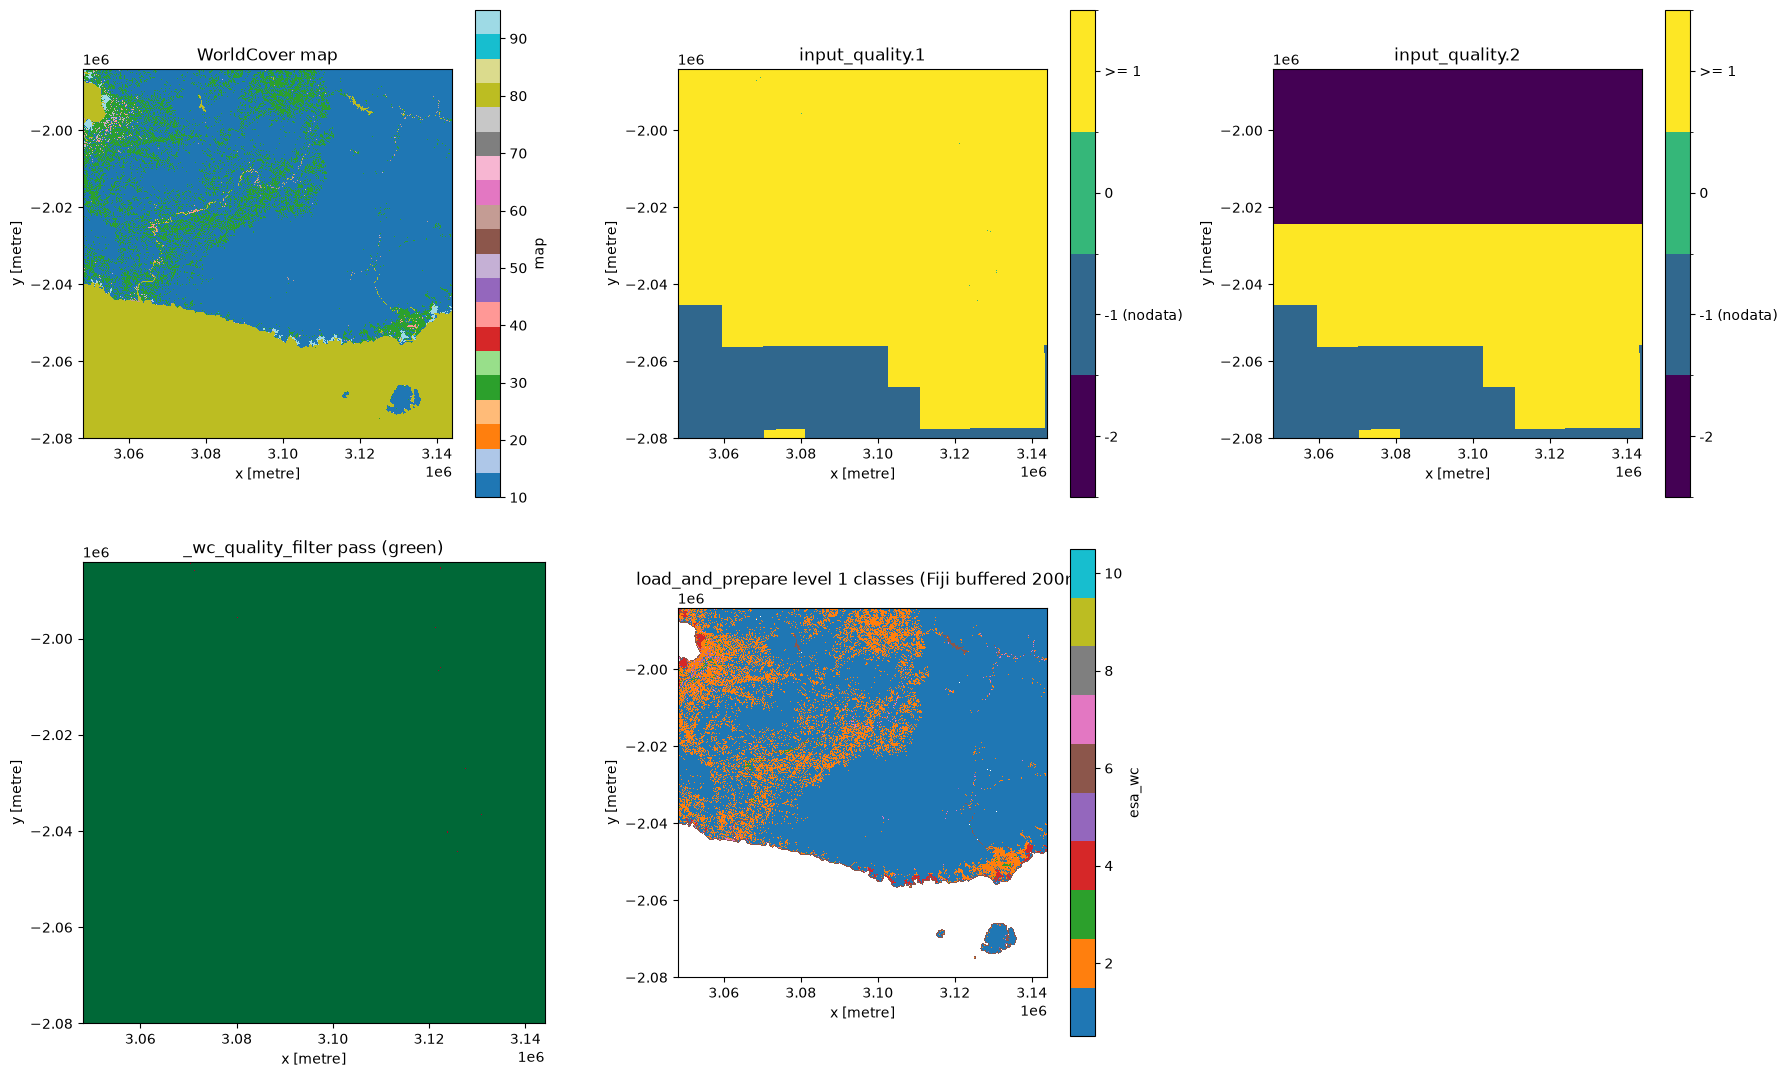

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
ds["map"].where(ds["map"] > 0).plot.imshow(ax=axes[0, 0], cmap="tab20", add_colorbar=True)
axes[0, 0].set_title("WorldCover map")
for ax, band in zip(axes.flat[1:3], quality_bands):
    # Categories: -2, -1 (nodata), 0, and 1 or more
    levels = [-2.5, -1.5, -0.5, 0.5, 1.5]
    im = ds[band].clip(max=1).plot.imshow(ax=ax, levels=levels, cmap="viridis", add_colorbar=False)
    cbar = fig.colorbar(im, ax=ax, ticks=[-2, -1, 0, 1])
    cbar.ax.set_yticklabels(["-2", "-1 (nodata)", "0", ">= 1"])
    ax.set_title(band)
_wc_quality_filter(ds).plot.imshow(ax=axes[1, 0], cmap="RdYlGn", vmin=0, vmax=1, add_colorbar=False)
axes[1, 0].set_title("_wc_quality_filter pass (green)")
prepared.where(prepared != product_nodata_value).plot.imshow(ax=axes[1, 1], cmap="tab10", vmin=0.5, vmax=10.5)
axes[1, 1].set_title("load_and_prepare level 1 classes (Fiji buffered 200m)")
axes[1, 2].axis("off")
for ax in axes.flat:
    ax.set_aspect("equal")
plt.tight_layout()